<a href="https://colab.research.google.com/github/brishti-c/undergrad_ml_assignments/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

The MSE is almost zero (with an order of magnitude of -30).

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

Using 5-fold cross-validation, the linear regression model produced mean squared errors that were much higher than the near-zero training MSE, and there was noticeable variability across the folds. From a bias-variance perspective, the OLS model has very low bias because it can fit any pattern in the training data. However, it has extremely high variance due to the large number of features relative to samples. Small changes in the training data cause large changes in the model’s predictions, which explains the poor performance on the cross-validation folds. It is overfitting.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

Cross-validated LASSO selects a small subset of highly predictive genes while discarding most of the others. Out of 7,129 genes, only a limited number have nonzero coefficients, and the rest are removed from the model. The scatterplot of predicted versus actual values shows that LASSO predictions generalize better than OLS, avoiding overfitting while capturing key patterns.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

The plot shows how gene coefficients change as α varies. For large α values around 0.01, nearly all coefficients are shrunk to zero, causing underfitting. For very small α values around 0.0001, many coefficients are nonzero and fluctuate, leading to overfitting. The optimal α is approximately 0.001, marked by the green dashed line, where only a subset of genes has nonzero coefficients. At this value, the cross-validated MSE is minimized, achieving the best balance between bias and variance.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs perfectly on the training set because there are far more features (~7,000 genes) than samples (72 patients), allowing it to exactly fit the data, including noise. However, this leads to overfitting and poor generalization. LASSO adds a penalty that shrinks and removes many coefficients, reducing model complexity and preventing overfitting, which results in better predictions on new data.

7. Why do regularization methods lend themselves to scenarios like precision health?

Precision health datasets are high-dimensional and often noisy, with many more variables than observations. Regularization methods like LASSO help by selecting a small set of important features, improving interpretability and reducing overfitting. This makes models more stable and reliable for predicting patient outcomes.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

LASSO may select genes that only appear predictive due to noise, leading to misleading conclusions. The selected features can also change with small variations in the data, reducing reliability. Additionally, important correlated genes may be excluded, and if clinical decisions are based on these models, incorrect predictions could result in harmful or ineffective treatments.

In [6]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')

# Relabel outcome
mapper = {'allB':0, 'allT':0, 'aml':1}
df['outcome'] = df['cancer'].map(mapper)

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


OLS training MSE: 1.2522824482837894e-30


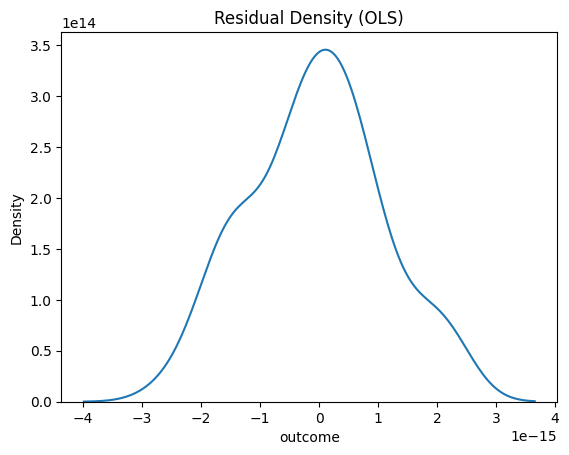

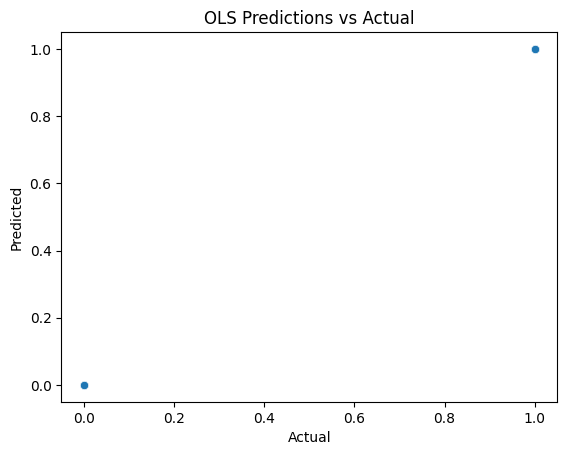

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# MSE function
mse = lambda y,y_hat : np.mean((y-y_hat)**2)

y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer','outcome'],axis=1)

model = LinearRegression()
reg = model.fit(X,y)

y_hat = reg.predict(X)

print(f'OLS training MSE: {mse(y,y_hat)}')

# Residual KDE plot
residuals = y_hat - y
sns.kdeplot(residuals)
plt.title("Residual Density (OLS)")
plt.show()

# Scatter plot (predicted vs actual)
sns.scatterplot(x=y, y=y_hat)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("OLS Predictions vs Actual")
plt.show()

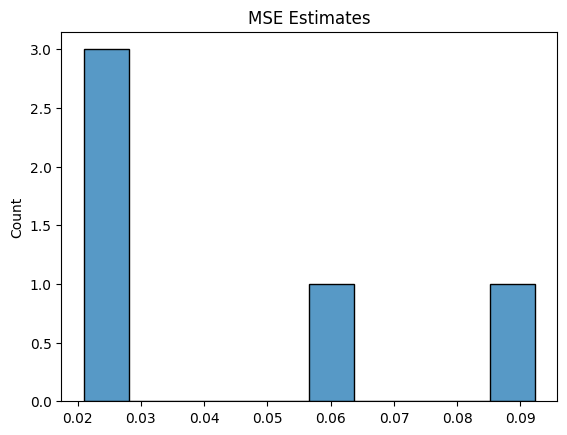

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984


In [8]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=100)

scores = cross_val_score(
    model, X, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

mse = -scores

# Plot distribution of CV errors
sns.histplot(mse, bins=10).set(title='MSE Estimates')
plt.show()

print("Fold scores:", mse)
print("Mean score:", np.mean(mse))
print("Median score:", np.median(mse))
print("Std dev:", np.std(mse))

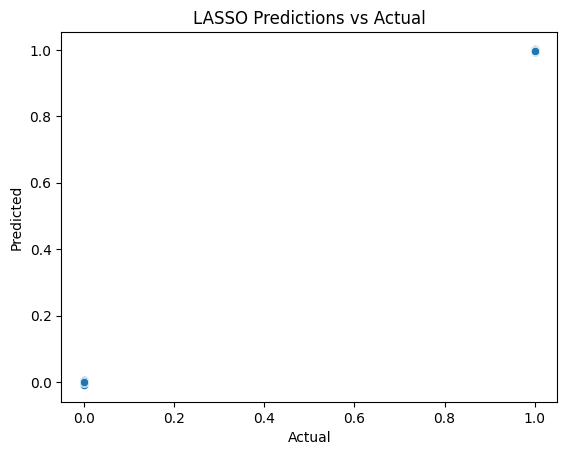

Selected Genes:
 Index(['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at',
       'K02777_s_at',

In [9]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

# Standardize data
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# LASSO CV
alpha_grid = np.logspace(-4, -2, num=50)
model = LassoCV(cv=10,
                alphas=alpha_grid,
                max_iter=50000,
                random_state=100)
model = model.fit(X_sc, y)

# Optimal alpha
alpha_star = model.alpha_

# Index of best alpha
index_star = np.argmin(np.mean(model.mse_path_, axis=1))

# Fit final LASSO
lasso = Lasso(alpha=alpha_star, max_iter=50000)
lasso.fit(X_sc, y)

# Coefficients
coefs_star = lasso.coef_

# Predictions
y_hat_lasso = lasso.predict(X_sc)

# Scatterplot (predicted vs actual)
sns.scatterplot(x=y, y=y_hat_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO Predictions vs Actual")
plt.show()

# Selected genes (nonzero coefficients)
nonzero_idx = np.where(coefs_star != 0)[0]
selected_genes = X.columns[nonzero_idx]

print("Selected Genes:\n", selected_genes)
print("Number selected:", len(selected_genes))
print("Total genes:", X.shape[1])
print("Discarded:", X.shape[1] - len(selected_genes))

Optimal cost hyperparameter: 0.0006551285568595509


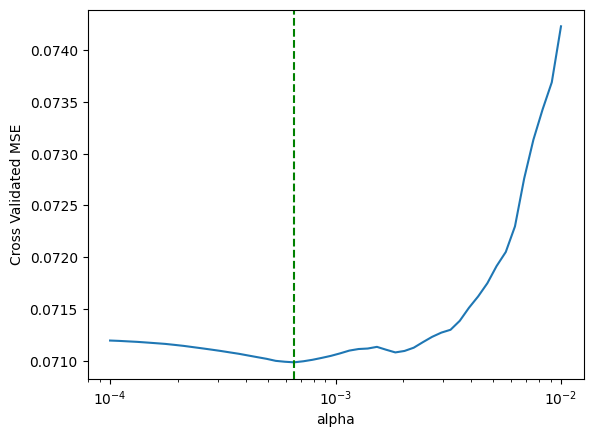

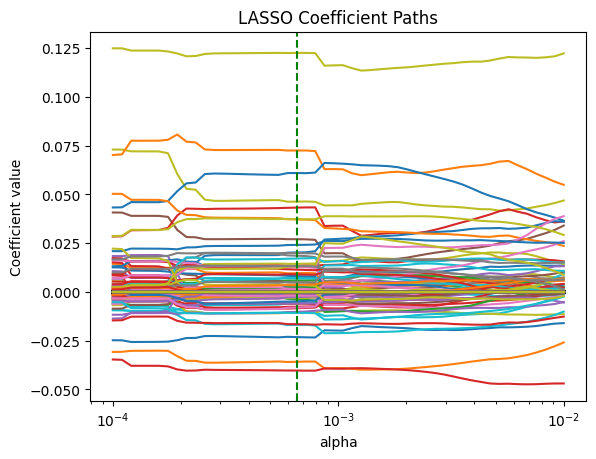

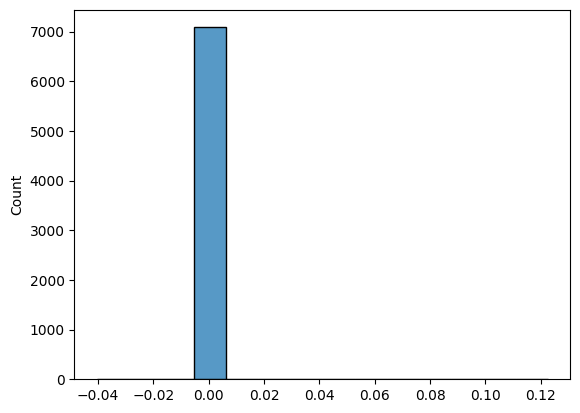

Selected Genes:
 Index(['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at',
       'K02777_s_at',

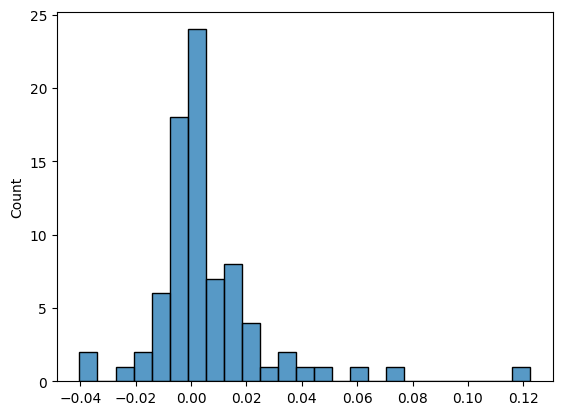

Nonzero coefficients: 80
Total genes: 7129


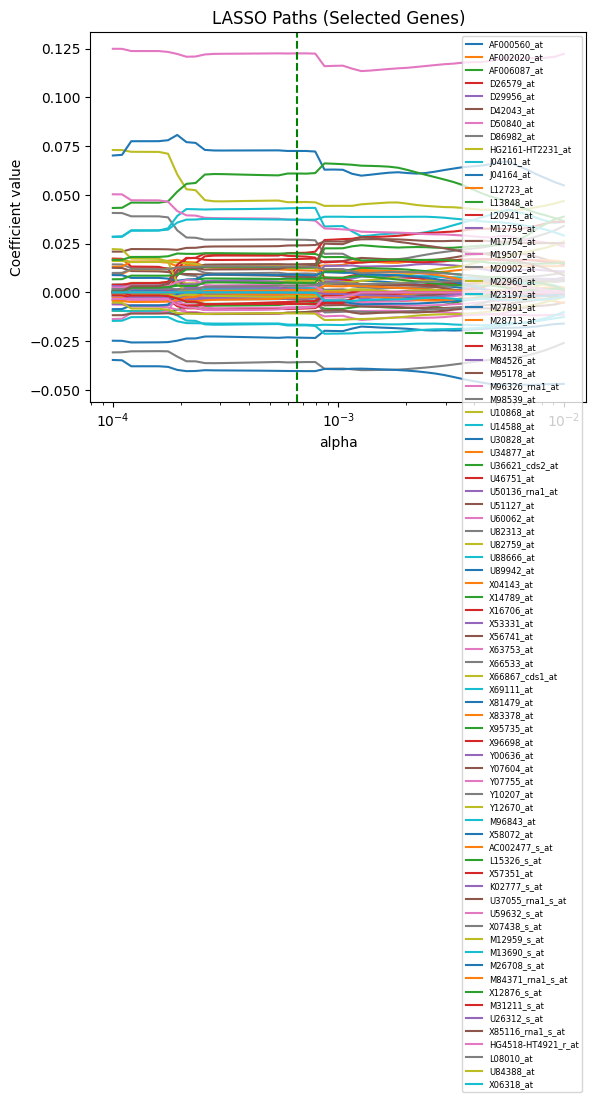

In [10]:
# 5. Cross validated MSE versus alpha

sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')
plt.show()

coefs = []
for alpha in model.alphas_: # For each alpha value,
    reg = Lasso(alpha=alpha, max_iter=10_000) # Create a lasso model
    reg = reg.fit(X_sc,y) # Run the regression
    coefs.append(reg.coef_) # Save the slope coefficients
coefs = np.array(coefs) # Cast list of lists to array

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

coefs_star = coefs[index_star]
sns.histplot( coefs_star )
plt.show()

nonzero_indices = np.where( coefs_star != 0 )[0]
print('Selected Genes:\n', X.columns[nonzero_indices])
sns.histplot( coefs_star[nonzero_indices] )
plt.show()

print("Nonzero coefficients:", np.sum(coefs_star != 0))
print("Total genes:", len(coefs_star))

for i in nonzero_indices:
    plt.plot(model.alphas_, coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.axvline(alpha_star, linestyle="--", color="green")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Paths (Selected Genes)")
plt.legend(fontsize=6)
plt.show()